In [1]:
import os
import pandas as pd
import numpy as np
from src.wav_io import wav_metadata_reader, wav_reader
from src.spectrogram_analysis import spectrogram_resolution, spectrogram_analysis_nfft, pltSpect
from src.spl_utils import OctaveBandsCalculation, pltSPL

In [2]:
FontSize = 16
PSDmin,PSDmax = 30,140 # [dB re 1uPa^2/Hz]

NFFT = 2048
overlap_bin = 0.5

#### Synthetic Data Generation:

This cell runs the script that generates an example acoustic signal.
The output WAV file is saved in the "./results" folder

In [3]:
datapath2save = r"./results"
!python -m scripts.generate_example_data --output_results {datapath2save}

INFO:__main__:...generate_example_data finalize!


#### Read/Load the signal:

In [4]:
FileName = "example_data"
WAVname = fr"{datapath2save}\{FileName}.wav"
metadata_str = wav_metadata_reader(WAVname)
# print(f"Metadata read from wav file: {metadata_str}")
Nbits = metadata_str["Nbits"]
FS_uPa = metadata_str["FS_uPa"]
signal_uPa, fs, _ = wav_reader(WAVname,Nbits=Nbits,FS_uPa=FS_uPa)
signal_t = np.arange(0, len(signal_uPa) / fs, 1 / fs)
print(f"Max absolute value in signal_uPa: {np.max(np.abs(signal_uPa))}")

c:\Users\Didac\Documents\ddietor\LT-Acoustic-Feature-Extractor\src\wav_io.py:127: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal_samples = wavfile.read(str(wav_path))


Max absolute value in signal_uPa: 49135293962.50446


#### General parameters:

#### Spectrogram resolution:

In [5]:
Tbin, Fbin, Fvalid = spectrogram_resolution(NFFT, fs, overlap=overlap_bin)
print(f"{NFFT}-NFFT and {overlap_bin*100:.0f}% overlap (fs:{int(fs/1e3)} kHz) -> Fbin:{Fbin:.1f} Hz, Tbin:{Tbin:.3f} s, Fvalid:{Fvalid:.1f} Hz")

2048-NFFT and 50% overlap (fs:192 kHz) -> Fbin:93.8 Hz, Tbin:0.005 s, Fvalid:187.5 Hz


### Section 1 - High-frequency analysis
#### 1.1 PSDdata 
##### 1.1.1 PSDdata calculation:

In [6]:
tspect,fspect,psd,spect_info = spectrogram_analysis_nfft(signal_uPa,fs,NFFT=NFFT,overlap=overlap_bin,plotter=False)
tspect = tspect + signal_t[0]
_,tbin,fbin,fvalid,_ = spect_info

Nvalid = np.where(fspect >= fvalid)[0][0]
fspect = fspect[Nvalid:]
psd = psd[Nvalid:,:]

PSD_high = np.column_stack([np.append(np.nan,fspect),np.vstack([tspect,psd])])

##### 1.1.2 PSDdata representation:

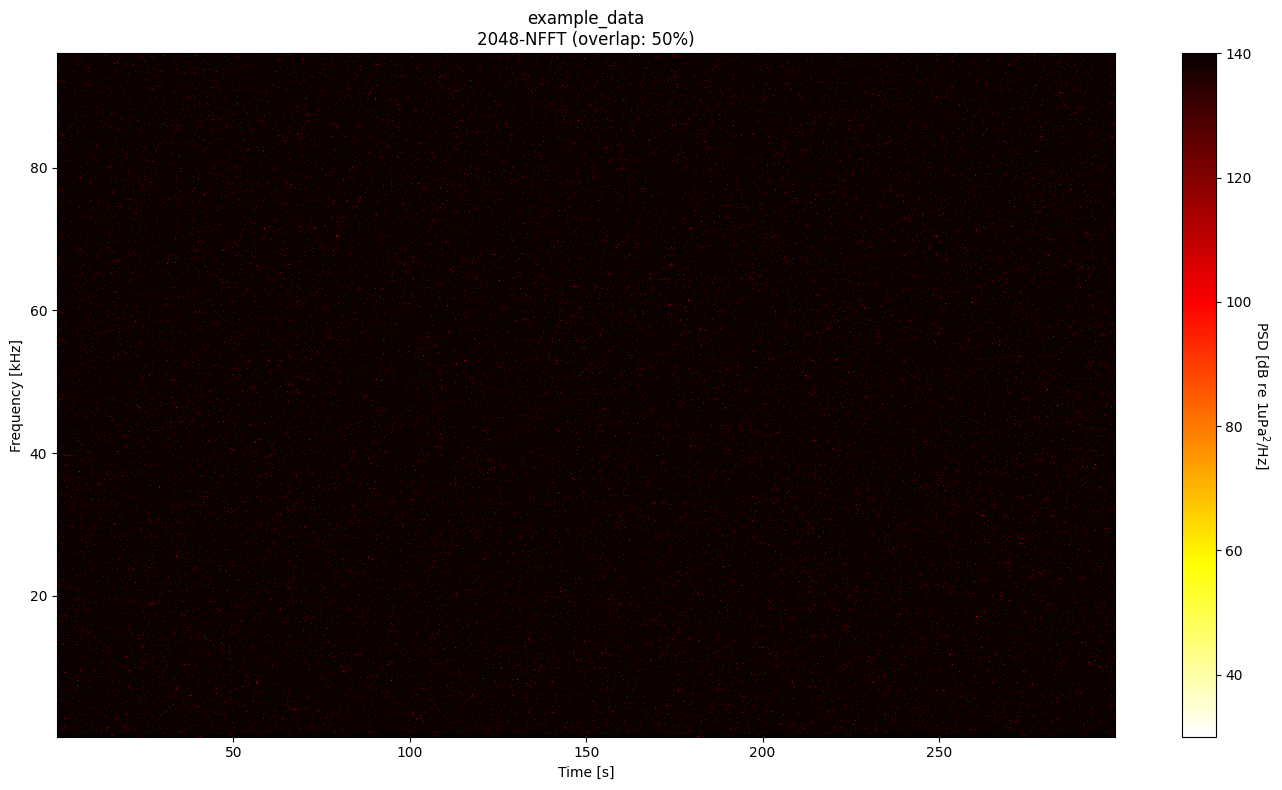

In [7]:
SpectName = FileName + '_PSDdata'
title_str = f'{FileName}\n{NFFT}-NFFT (overlap: {int(overlap_bin*100)}%)'
pltSpect(psd, tspect, fspect, spect_info, PSDmin=PSDmin, PSDmax=PSDmax, title_str=title_str, CbarLabel='PSD [dB re 1uPa$^2$/Hz]', path2save=datapath2save, filename=SpectName)
   

##### 1.1.3 PSDdata saver:

In [8]:
save_PSDdata_csv = False
if save_PSDdata_csv:
    psd2csv = np.column_stack([np.append(np.nan,fspect),np.vstack([tspect,psd])])
    csvData = pd.DataFrame(psd2csv)
    csvData.to_csv(os.path.join(datapath2save,SpectName+'.csv'),index=False,header=False,sep =';')  

#### 1.2 SPLdata 
##### 1.2.1 SPLdata calculation:

In [9]:
OctaveBands_fs = OctaveBandsCalculation(fs,octave=1/3) 
OctaveBands = OctaveBands_fs[OctaveBands_fs['fini'] >= min(fspect[fspect>=fvalid])]
OctaveBands = OctaveBands.reset_index(drop=True)
spl = np.ones((len(OctaveBands),len(tspect)))*np.nan
row2del = []
for j in range(len(OctaveBands)):
    row = OctaveBands.iloc[j]
    fini = row['fini']
    fend = row['fend']
    indxs = np.where((fspect >= fini) & (fspect <= fend))[0]
    if len(indxs)>1:
        spl[j,:] = 10*np.log10(np.sum(10**(psd[indxs,:]/10)*fbin, axis=0))
    elif len(indxs)==1: 
        spl[j,:] = 10*np.log10(10**(psd[indxs,:]/10)*fbin)
    elif len(indxs)==0:
        row2del.append(j)
if len(row2del)>0:
    spl = np.delete(spl, row2del, axis=0)
    OctaveBands = OctaveBands.drop(row2del)

SPL_high = np.column_stack([np.append(np.nan,OctaveBands['fc'].values),np.vstack([tspect,spl])])

##### 1.2.2 SPLdata representation:

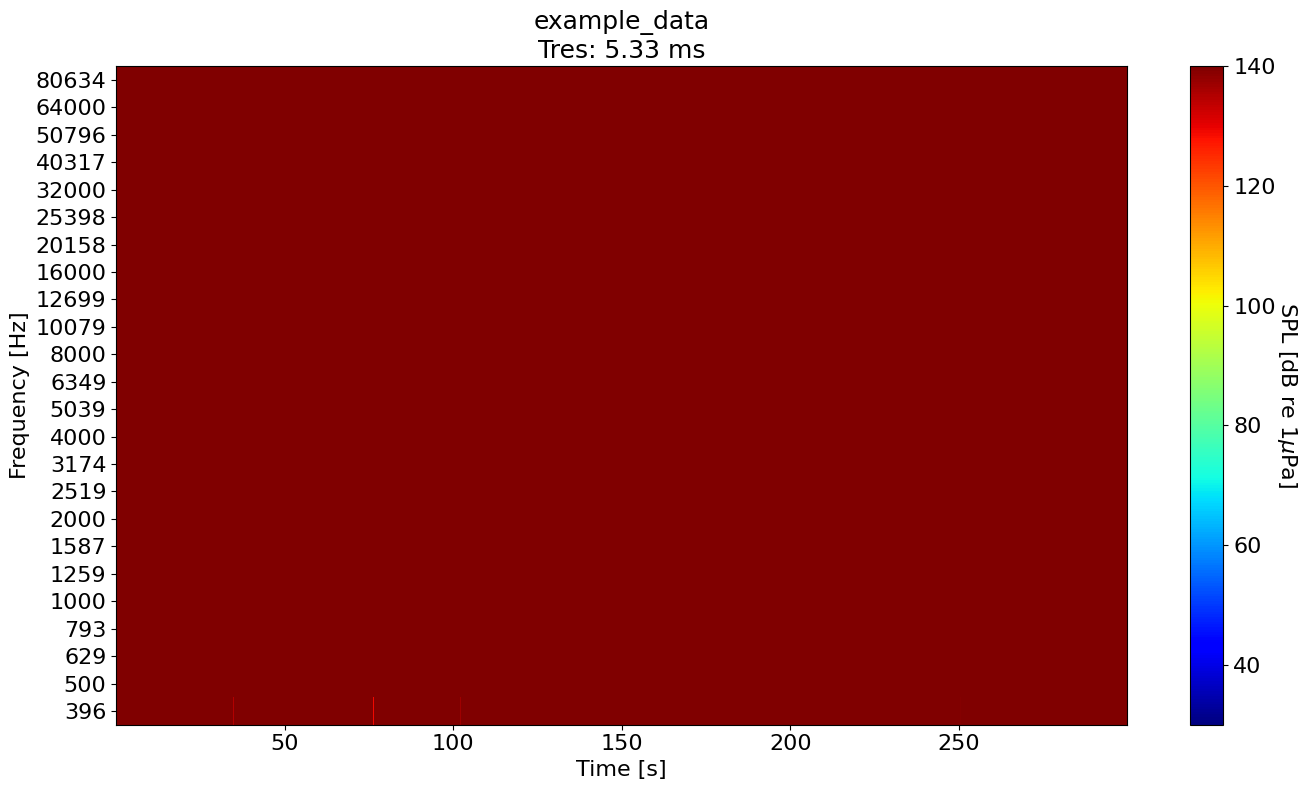

In [10]:
SplName = FileName + '_SPLdata'
pltSPL(spl, tspect, OctaveBands, FileName=FileName, SPLmin=PSDmin, SPLmax=PSDmax, FontSize=FontSize, c_map='jet', path2save=datapath2save, filename=SplName)

##### 1.2.3 SPLdata saver:

In [11]:
save_SPLdata_csv = True
if save_SPLdata_csv:
    spl2csv = np.column_stack([np.append(np.nan,OctaveBands['fc'].values),np.vstack([tspect,spl])])
    csvData = pd.DataFrame(spl2csv)
    csvData.to_csv(os.path.join(datapath2save,SplName+'.csv'),index=False,header=False,sep =';') 